In [23]:
import meep as mp
import numpy as np
import numpy.matlib
import matplotlib.pyplot as plt

resolution = 30 # pixels/um

dpml = 1.0 #PML thickness
dsub = 3.0 #substrate thickness
dpad = dsub #passind between cell and PML

wvl_min = 1.5
wvl_max = 1.6
wvl_cen = 0.5*(wvl_min+wvl_max)
fmin = 1/wvl_max
fmax = 1/wvl_min
fcen = 0.5*(fmin+fmax)
df = fmax-fmin
nfreq = 10

k_point = mp.Vector3(0,0,0) #used for PBC

n_si = 3.43 #silicon refractive index
si = mp.Medium(index=n_si)
n_air = 1.0 #air refractive index
air = mp.Medium(index=n_air)

     block, center = (0,0,-2)
          size (1e+20,1e+20,4)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (11.7649,11.7649,11.7649)


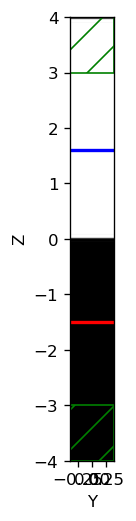

In [39]:
P = 0.8 #unit cell pitch
h = 0.8 #pillar height

sim_z_size = dpml + dsub + dpad + dpml
sim_x_size = P
sim_y_size = P

substrate_geo = mp.Block(
    material = si,
    size = mp.Vector3(mp.inf, mp.inf, dsub+dpml),
    center = mp.Vector3(0,0,-(dsub+dpml)/2),
)

source_position = mp.Vector3(0,0,-dsub/2) #source position in the middle of the substrate
source = mp.Source(
    mp.GaussianSource(fcen, fwidth=df),
    component = mp.Ex,
    center = source_position,
    size = mp.Vector3(sim_x_size, sim_y_size, 0),
)

cell_size = mp.Vector3(sim_x_size, sim_y_size, sim_z_size)
pml_layers = [mp.PML(dpml,direction=mp.Z)]

sim = mp.Simulation(
    resolution = resolution,
    cell_size = cell_size,
    boundary_layers = pml_layers,
    sources = [source],
    geometry = [substrate_geo],
    default_material = air,
    k_point = k_point,
)

monitor_position = mp.Vector3(0,0,2*h)
flux_mon = sim.add_flux(
    fcen, df, nfreq, mp.FluxRegion(center=monitor_position, size=mp.Vector3(sim_x_size, sim_y_size, 0))
)

f = plt.figure(dpi=120)
yz_plane = mp.Volume(center=mp.Vector3(0,0,0), size=mp.Vector3(0,sim_y_size,sim_z_size))
sim.plot2D(ax=f.gca(),output_plane=yz_plane,show_sources=True,show_monitors=True)
plt.show()


-----------
Initializing structure...
time for choose_chunkdivision = 5.50747e-05 s
Working in 3D dimensions.
Computational cell is 0.8 x 0.8 x 8 with resolution 30
     block, center = (0,0,-2)
          size (1e+20,1e+20,4)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (11.7649,11.7649,11.7649)
time for set_epsilon = 0.628286 s
-----------


FloatProgress(value=0.0, description='0% done ', max=340.0)

Meep progress: 15.25/340.0 = 4.5% done in 4.0s, 85.3s to go
on time step 916 (time=15.2667), 0.00437052 s/step
Meep progress: 32.083333333333336/340.0 = 9.4% done in 8.0s, 76.8s to go
on time step 1928 (time=32.1333), 0.0039538 s/step
Meep progress: 48.85/340.0 = 14.4% done in 12.0s, 71.6s to go
on time step 2935 (time=48.9167), 0.00397708 s/step
Meep progress: 64.48333333333333/340.0 = 19.0% done in 16.0s, 68.4s to go
on time step 3875 (time=64.5833), 0.0042569 s/step
Meep progress: 78.6/340.0 = 23.1% done in 20.0s, 66.6s to go
on time step 4721 (time=78.6833), 0.00473252 s/step
Meep progress: 94.3/340.0 = 27.7% done in 24.0s, 62.6s to go
on time step 5662 (time=94.3667), 0.00425366 s/step
Meep progress: 114.58333333333333/340.0 = 33.7% done in 28.0s, 55.1s to go
on time step 6883 (time=114.717), 0.00327709 s/step
Meep progress: 134.55/340.0 = 39.6% done in 32.0s, 48.9s to go
on time step 8083 (time=134.717), 0.0033351 s/step
Meep progress: 155.18333333333334/340.0 = 45.6% done in 36.

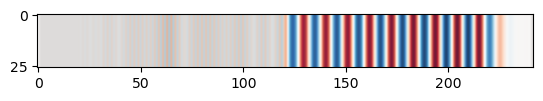

In [ ]:
obs_point = monitor_position
stop_cond = mp.stop_when_fields_decayed(25, mp.Ex, obs_point, 1e-6)
sim.run(until_after_sources=stop_cond)
eps_data = sim.get_array(center=mp.Vector3(), size=mp.Vector3(0,sim_y_size,sim_z_size), component=mp.Dielectric)
ex_data = sim.get_array(center=mp.Vector3(), size=mp.Vector3(0,sim_y_size,sim_z_size), component=mp.Ex)
plt.figure()
plt.imshow(eps_data, interpolation='spline36', cmap='binary')
plt.imshow(ex_data, interpolation='spline36', cmap='RdBu', alpha=0.9)
plt.show()

In [52]:
input_flux = mp.get_fluxes(flux_mon)

     block, center = (0,0,-2)
          size (1e+20,1e+20,4)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (11.7649,11.7649,11.7649)
     cylinder, center = (0,0,0.4)
          radius 0.05, height 0.8, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (11.7649,11.7649,11.7649)


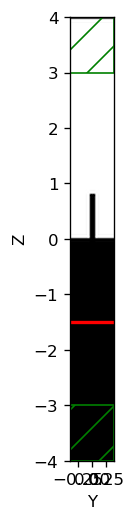

-----------
Initializing structure...
time for choose_chunkdivision = 8.60691e-05 s
Working in 3D dimensions.
Computational cell is 0.8 x 0.8 x 8 with resolution 30
     block, center = (0,0,-2)
          size (1e+20,1e+20,4)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (11.7649,11.7649,11.7649)
     cylinder, center = (0,0,0.4)
          radius 0.05, height 0.8, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (11.7649,11.7649,11.7649)
time for set_epsilon = 0.721498 s
-----------


FloatProgress(value=0.0, description='0% done ', max=300.00023999999394)

Meep progress: 10.366666666666667/300.00023999999394 = 3.5% done in 4.0s, 111.9s to go
on time step 623 (time=10.3833), 0.00642495 s/step
Meep progress: 26.333333333333332/300.00023999999394 = 8.8% done in 8.0s, 83.2s to go
on time step 1582 (time=26.3667), 0.00417335 s/step
Meep progress: 44.53333333333333/300.00023999999394 = 14.8% done in 12.0s, 68.9s to go
on time step 2674 (time=44.5667), 0.00366696 s/step
Meep progress: 63.233333333333334/300.00023999999394 = 21.1% done in 16.0s, 59.9s to go
on time step 3798 (time=63.3), 0.00355943 s/step
Meep progress: 81.88333333333333/300.00023999999394 = 27.3% done in 20.0s, 53.3s to go
on time step 4918 (time=81.9667), 0.00357388 s/step
Meep progress: 99.96666666666667/300.00023999999394 = 33.3% done in 24.0s, 48.0s to go
on time step 6002 (time=100.033), 0.00369273 s/step
Meep progress: 116.23333333333333/300.00023999999394 = 38.7% done in 28.0s, 44.3s to go
on time step 6979 (time=116.317), 0.00409807 s/step
Meep progress: 131.96666666666

/tmp/ipykernel_41021/3049005185.py:42: RuntimeWarning: invalid value encountered in scalar divide
  mode_tran = [abs(coeffs[0,nf,0])**2 / input_flux[nf] for nf in range(nfreq)]


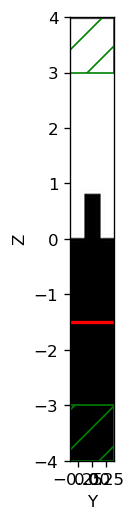

-----------
Initializing structure...
time for choose_chunkdivision = 7.39098e-05 s
Working in 3D dimensions.
Computational cell is 0.8 x 0.8 x 8 with resolution 30
     block, center = (0,0,-2)
          size (1e+20,1e+20,4)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (11.7649,11.7649,11.7649)
     cylinder, center = (0,0,0.4)
          radius 0.15, height 0.8, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (11.7649,11.7649,11.7649)
time for set_epsilon = 0.704258 s
-----------


FloatProgress(value=0.0, description='0% done ', max=300.00023999999394)

Meep progress: 13.816666666666666/300.00023999999394 = 4.6% done in 4.0s, 82.9s to go
on time step 830 (time=13.8333), 0.00482221 s/step
Meep progress: 28.65/300.00023999999394 = 9.5% done in 8.0s, 75.8s to go
on time step 1720 (time=28.6667), 0.00449722 s/step
Meep progress: 43.516666666666666/300.00023999999394 = 14.5% done in 12.0s, 70.8s to go
on time step 2612 (time=43.5333), 0.00448448 s/step
Meep progress: 59.55/300.00023999999394 = 19.8% done in 16.0s, 64.7s to go
on time step 3574 (time=59.5667), 0.00415846 s/step
Meep progress: 76.35/300.00023999999394 = 25.4% done in 20.0s, 58.6s to go
on time step 4583 (time=76.3833), 0.00396919 s/step
Meep progress: 92.7/300.00023999999394 = 30.9% done in 24.0s, 53.7s to go
on time step 5566 (time=92.7667), 0.00407131 s/step
Meep progress: 111.8/300.00023999999394 = 37.3% done in 28.0s, 47.2s to go
on time step 6712 (time=111.867), 0.00349482 s/step
Meep progress: 130.61666666666667/300.00023999999394 = 43.5% done in 32.0s, 41.5s to go
on 

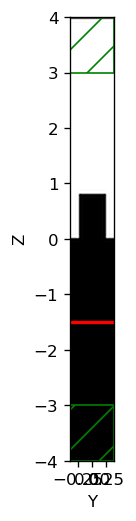

-----------
Initializing structure...
time for choose_chunkdivision = 7.70092e-05 s
Working in 3D dimensions.
Computational cell is 0.8 x 0.8 x 8 with resolution 30
     block, center = (0,0,-2)
          size (1e+20,1e+20,4)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (11.7649,11.7649,11.7649)
     cylinder, center = (0,0,0.4)
          radius 0.25, height 0.8, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (11.7649,11.7649,11.7649)
time for set_epsilon = 0.866202 s
-----------


FloatProgress(value=0.0, description='0% done ', max=300.00023999999394)

Meep progress: 13.816666666666666/300.00023999999394 = 4.6% done in 4.0s, 82.9s to go
on time step 830 (time=13.8333), 0.00481963 s/step
Meep progress: 26.316666666666666/300.00023999999394 = 8.8% done in 8.0s, 83.2s to go
on time step 1580 (time=26.3333), 0.00534261 s/step
Meep progress: 36.083333333333336/300.00023999999394 = 12.0% done in 12.0s, 87.8s to go
on time step 2167 (time=36.1167), 0.00681576 s/step
Meep progress: 50.15/300.00023999999394 = 16.7% done in 16.0s, 79.8s to go
on time step 3012 (time=50.2), 0.00473832 s/step
Meep progress: 64.6/300.00023999999394 = 21.5% done in 20.0s, 72.9s to go
on time step 3884 (time=64.7333), 0.00459009 s/step
Meep progress: 79.88333333333333/300.00023999999394 = 26.6% done in 24.0s, 66.2s to go
on time step 4801 (time=80.0167), 0.00436337 s/step
Meep progress: 97.83333333333333/300.00023999999394 = 32.6% done in 28.0s, 57.9s to go
on time step 5877 (time=97.95), 0.00371863 s/step
Meep progress: 114.98333333333333/300.00023999999394 = 38.3

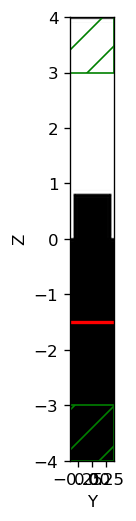

-----------
Initializing structure...
time for choose_chunkdivision = 5.81741e-05 s
Working in 3D dimensions.
Computational cell is 0.8 x 0.8 x 8 with resolution 30
     block, center = (0,0,-2)
          size (1e+20,1e+20,4)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (11.7649,11.7649,11.7649)
     cylinder, center = (0,0,0.4)
          radius 0.35, height 0.8, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (11.7649,11.7649,11.7649)
time for set_epsilon = 0.812415 s
-----------


FloatProgress(value=0.0, description='0% done ', max=300.00023999999394)

Meep progress: 14.233333333333333/300.00023999999394 = 4.7% done in 4.0s, 80.3s to go
on time step 855 (time=14.25), 0.00467964 s/step
Meep progress: 29.216666666666665/300.00023999999394 = 9.7% done in 8.0s, 74.2s to go
on time step 1755 (time=29.25), 0.00444807 s/step
Meep progress: 45.71666666666667/300.00023999999394 = 15.2% done in 12.0s, 66.8s to go
on time step 2744 (time=45.7333), 0.00404536 s/step
Meep progress: 61.53333333333333/300.00023999999394 = 20.5% done in 16.0s, 62.0s to go
on time step 3694 (time=61.5667), 0.0042123 s/step
Meep progress: 76.8/300.00023999999394 = 25.6% done in 20.0s, 58.2s to go
on time step 4611 (time=76.85), 0.00436382 s/step
Meep progress: 92.71666666666667/300.00023999999394 = 30.9% done in 24.0s, 53.7s to go
on time step 5566 (time=92.7667), 0.00419006 s/step
Meep progress: 112.78333333333333/300.00023999999394 = 37.6% done in 28.0s, 46.5s to go
on time step 6772 (time=112.867), 0.00331882 s/step
Meep progress: 133.68333333333334/300.00023999999

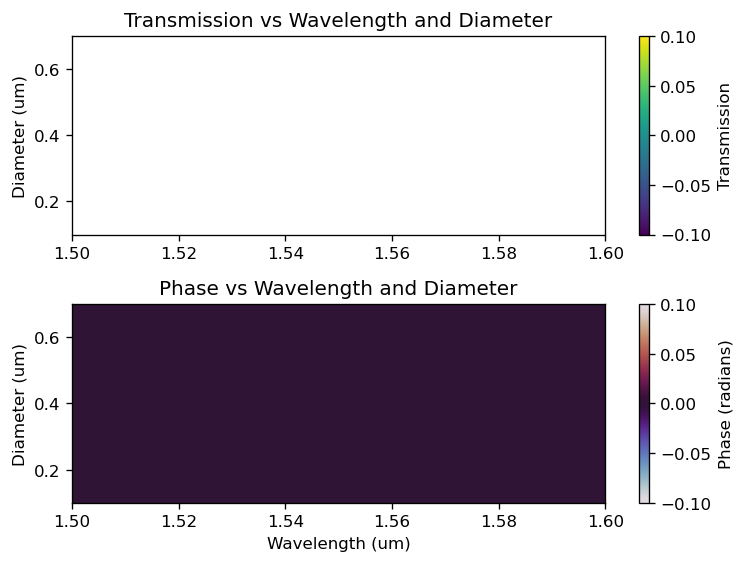

In [ ]:
sim.reset_meep()

def make_unit_cell(D):
    pillar_geo = mp.Cylinder(
        material = si,
        radius = D/2,
        height = h,
        center = mp.Vector3(0,0,h/2),
    )
    return pillar_geo

def make_unit_cell_sim(D):
    pillar_geo = make_unit_cell(D)
    geometries = [substrate_geo, pillar_geo]

    sim = mp.Simulation(
        resolution = resolution,
        cell_size = cell_size,
        boundary_layers = pml_layers,
        geometry = geometries,
        default_material = air,
        k_point = k_point,
        sources = [source],
    )
    f = plt.figure(dpi=120)
    sim.plot2D(ax=f.gca(),output_plane=yz_plane,show_sources=True,show_monitors=True)
    plt.show()

    mode_mon = sim.add_flux(
        fcen, df, nfreq, mp.FluxRegion(center=monitor_position, size=mp.Vector3(sim_x_size, sim_y_size, 0))
    )
    sim.run(until_after_sources=300)

    freqs = mp.get_eigenmode_freqs(mode_mon)
    res = sim.get_eigenmode_coefficients(
        mode_mon, [1], eig_parity=mp.EVEN_Y
    )
    coeffs = res.alpha

    mode_wvl = [1/freqs[nf] for nf in range(nfreq)]
    mode_tran = [abs(coeffs[0,nf,0])**2 / input_flux[nf] for nf in range(nfreq)]
    mode_phase = [np.angle(coeffs[0,nf,0]) for nf in range(nfreq)]

    return mode_wvl, mode_tran, mode_phase

diameters = np.linspace(0.1, 0.7, 4)
mode_tran_arr = np.empty((len(diameters), nfreq))
mode_phase_arr = np.empty((len(diameters), nfreq))

for i, D in enumerate(diameters):
    mode_wvl, mode_tran, mode_phase = make_unit_cell_sim(D)
    mode_tran_arr[i,:] = mode_tran
    mode_phase_arr[i,:] = mode_phase

#make a 2d plot of the transmission and phase as a function of wavelength and diameter
plt.figure(dpi=120)
plt.subplot(2,1,1)
plt.imshow(mode_tran_arr, extent=[wvl_min*1e6, wvl_max*1e6, diameters[0], diameters[-1]], aspect='auto', origin='lower', cmap='viridis')
plt.colorbar(label='Transmission')
plt.ylabel('Diameter (um)')
plt.title('Transmission vs Wavelength and Diameter')
plt.subplot(2,1,2)
plt.imshow(mode_phase_arr, extent=[wvl_min*1e6, wvl_max*1e6, diameters[0], diameters[-1]], aspect='auto', origin='lower', cmap='twilight')
plt.colorbar(label='Phase (radians)')
plt.ylabel('Diameter (um)')
plt.xlabel('Wavelength (um)')
plt.title('Phase vs Wavelength and Diameter')
plt.tight_layout()
plt.show()

In [7]:
print(input_flux[0])

0.0
